# Data Profiler Project

## Objective
The goal of this project is to clean, transform, and analyze data from multiple sources such as CSV, JSON, and API. The final aim is to prepare a dataset suitable for machine learning.

## Problem Statement
We are working as a junior data analyst to analyze customer data and prepare it for predicting customer churn.

---

##  Part A: Basics

###  Importing Required Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# for ignoring warnings
# import warnings
# warnings.filterwarnings("ignore")

##  Part B: Data Collection

###  Loading Data from Multiple Sources (CSV, JSON, API)

In [25]:
# load csv file
customers = pd.read_csv("../data/raw/customers.csv")

# load json file
transactions = pd.read_json("../data/raw/transactions.json")

# load api data (simulated json)
api_data = pd.read_json("../data/raw/api_data.json")

# check first few rows
customers.head()

,customer_id,age,gender,income,purchase_amount,churn
0,1,56.0,Female,71005.0,4104.63,0
1,2,69.0,Male,66576.0,NaN,1
2,3,46.0,Female,500000.0,8524.19,1
3,4,32.0,Male,NaN,9362.79,1
4,5,60.0,Male,103211.0,7874.87,1


##  Data Understanding

- Checking structure of dataset  
- Viewing summary statistics  

In [26]:
# basic info about dataset
customers.info()

# statistical summary
customers.describe()

# check columns
customers.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125 entries, 0 to 124
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      125 non-null    int64  
 1   age              115 non-null    float64
 2   gender           125 non-null    object 
 3   income           114 non-null    float64
 4   purchase_amount  114 non-null    float64
 5   churn            125 non-null    int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 6.0+ KB


Index(['customer_id', 'age', 'gender', 'income', 'purchase_amount', 'churn'], dtype='object')

##  Part C: Data Cleaning

###  Handling Missing Values, Duplicates, and Data Issues

In [27]:
# check missing values
customers.isnull().sum()

# fill missing values with mean (simple method)
customers["income"].fillna(customers["income"].mean(), inplace=True)

# remove duplicate rows
customers.drop_duplicates(inplace=True)

# check again
customers.isnull().sum()

customer_id         0
age                10
gender              0
income              0
purchase_amount    10
churn               0
dtype: int64

###  Outlier Detection and Removal

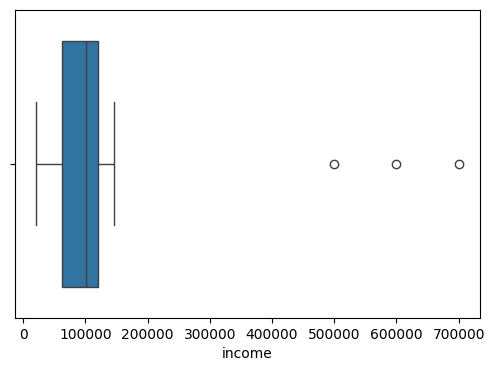

In [28]:
# visualize outliers using boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=customers["income"])
plt.show()

# remove extreme outliers (simple filtering)
customers = customers[customers["income"] < 300000]

##  Part D: Exploratory Data Analysis (EDA)

###  Univariate Analysis

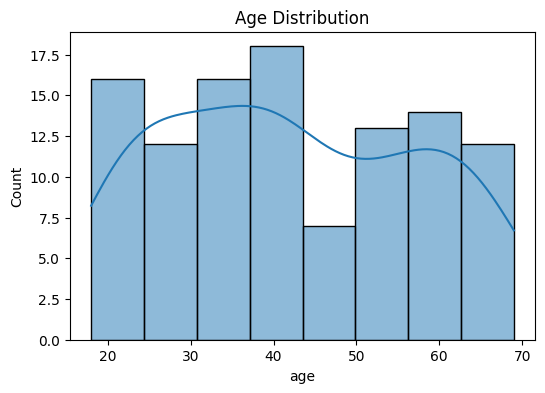

Insight: Most customers fall in mid-age group.


In [29]:
# distribution of age
plt.figure(figsize=(6,4))
sns.histplot(customers["age"], kde=True)
plt.title("Age Distribution")
plt.savefig("../reports/figures/univariate.png", dpi=300, bbox_inches="tight")
plt.show()
print("Insight: Most customers fall in mid-age group.")

###  Bivariate Analysis

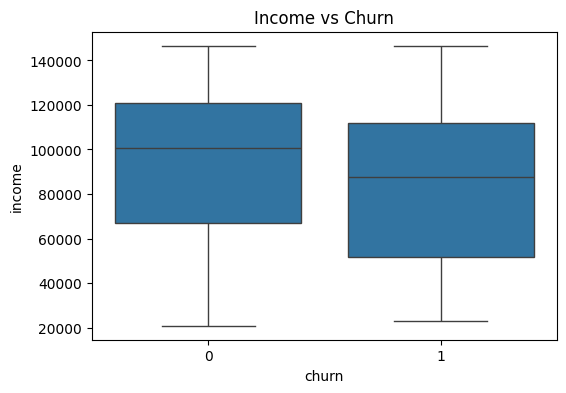

Insight: Customers with higher income tend to churn less.


In [30]:
# income vs churn
plt.figure(figsize=(6,4))
sns.boxplot(x="churn", y="income", data=customers)
plt.title("Income vs Churn")
plt.savefig("../reports/figures/bivariate.png", dpi=300, bbox_inches="tight")
plt.show()
print("Insight: Customers with higher income tend to churn less.")

###  Multivariate Analysis

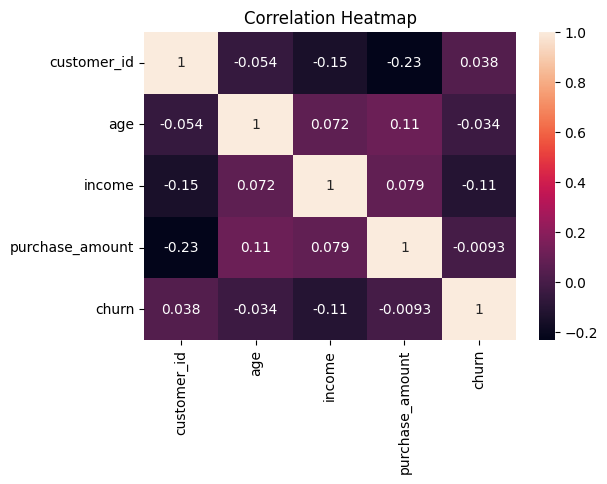

In [31]:
# correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(customers.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("../reports/figures/heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

##  Part E: Data Profiling

###  Generating Automated Data Report

In [ ]:
from ydata_profiling import ProfileReport   # Does better work withing python version 3.12

# load your cleaned dataset
df = pd.read_csv("cleaned_data.csv")

# create report
profile = ProfileReport(df, explorative=True)

# save as html
profile.to_file("../reports/profiling_report.html")

##  Saving Processed Data

In [32]:
customers.to_csv("../data/processed/cleaned_data.csv", index=False)

---

##  Conclusion

- Missing values and duplicates were handled properly  
- Outliers were identified and removed  
- Data was explored using univariate, bivariate, and multivariate analysis  
- Final cleaned dataset is ready for machine learning  

👉 This project demonstrates real-world data preprocessing and analysis workflow.

---
---